Mounted at /content/drive
Base do Filtro Binário extraída com sucesso!

Configurando geradores de imagens...
Found 16284 images belonging to 2 classes.
Found 2415 images belonging to 2 classes.
Found 6632 images belonging to 2 classes.

Carregando ResNet50 e configurando FASE 1...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Iniciando Fase 1: Aquecimento das camadas...
Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 451s 857ms/step - accuracy: 0.7486 - loss: 0.5071 - val_accuracy: 0.7909 - val_loss: 0.4307 - learning_rate: 0.0010
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 415s 815ms/step - accuracy: 0.7801 - loss: 0.4461 - val_accuracy: 0.7867 - val_loss: 0.4244 - learning_rate: 0.0010
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 405s 797ms/step - accuracy: 0.7889 - loss: 0.4359 - val_accuracy: 0.7863 - val_loss: 0.4357 - learning_rate: 0.0010
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 405s 796ms/step - accuracy: 0.7928 - loss: 0.4274 - val_accuracy: 0.7855 - val_loss: 0.4220 - learning_rate: 0.001

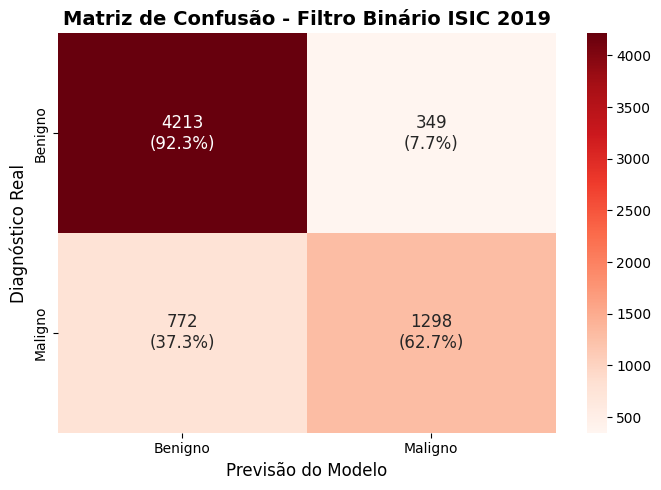

In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

drive.mount('/content/drive')

!rm -rf /content/dataset_binario/
!unzip -q "/content/drive/MyDrive/Colab Notebooks/TCC/Datasets/Dataset_Filtro_Binario_ISIC_2019.zip" -d "/content/dataset_binario/"

base_dir = '/content/dataset_binario/'
if 'Dataset_Filtro_Binario_ISIC_2019' in os.listdir(base_dir):
    base_dir = os.path.join(base_dir, 'Dataset_Filtro_Binario_ISIC_2019')

train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Val')
test_dir = os.path.join(base_dir, 'Test')

caminho_salvamento = "/content/drive/MyDrive/Colab Notebooks/TCC/Modelos/ResNet50_Filtro_Binario_ISIC_2019.keras"
os.makedirs(os.path.dirname(caminho_salvamento), exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, vertical_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

callbacks_f1 = [
    ModelCheckpoint(caminho_salvamento, save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks_f1)

base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

callbacks_f2 = [
    ModelCheckpoint(caminho_salvamento, save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks_f2)

model_final = load_model(caminho_salvamento)
test_generator.reset()
previsoes_prob = model_final.predict(test_generator)

classes_preditas = (previsoes_prob > 0.5).astype("int32").flatten()
classes_reais = test_generator.classes
nomes_classes = list(test_generator.class_indices.keys())

print("\n--- Relatório de Classificação ---")
print(classification_report(classes_reais, classes_preditas, target_names=nomes_classes))

matriz_absoluta = confusion_matrix(classes_reais, classes_preditas)
matriz_porcentagem = matriz_absoluta.astype('float') / (matriz_absoluta.sum(axis=1)[:, np.newaxis] + 1e-9)

labels = [f"{v1}\n({v2:.1%})" for v1, v2 in zip(matriz_absoluta.flatten(), matriz_porcentagem.flatten())]
labels = np.asarray(labels).reshape(matriz_absoluta.shape)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_absoluta, annot=labels, fmt='', cmap='Reds', xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"size": 12})
plt.title('Matriz de Confusão - Filtro Binário ISIC 2019', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()